Device: cuda
Initial symbol: ^SPX


Fetching Yahoo option chains for ^SPX:   0%|          | 0/54 [00:00<?, ?it/s]

Final symbol: ^SPX
Spot S0: 7259.22021484375
Raw option chain shape: (12003, 20)


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,option_type,expiry,T,S0,K,k
0,SPXW260526C06375000,2026-04-23 18:56:06+00:00,6375.0,762.13,903.3,910.0,0.0,0.0,NaN,1.0,0.388121,True,REGULAR,USD,call,2026-05-26,0.054795,7259.220215,6375.0,-0.129888
1,SPXW260526C06575000,2026-04-23 14:08:30+00:00,6575.0,593.52,706.2,712.9,0.0,0.0,NaN,2.0,0.325736,True,REGULAR,USD,call,2026-05-26,0.054795,7259.220215,6575.0,-0.098998
2,SPXW260526C06600000,2026-04-23 14:08:30+00:00,6600.0,570.39,682.0,688.4,0.0,0.0,NaN,2.0,0.318099,True,REGULAR,USD,call,2026-05-26,0.054795,7259.220215,6600.0,-0.095203
3,SPXW260526C06800000,2026-05-04 15:02:18+00:00,6800.0,461.74,488.9,495.0,0.0,0.0,1.0,5.0,0.260132,True,REGULAR,USD,call,2026-05-26,0.054795,7259.220215,6800.0,-0.065350
4,SPXW260526C06825000,2026-04-20 15:58:01+00:00,6825.0,352.26,465.3,471.3,0.0,0.0,NaN,1.0,0.253345,True,REGULAR,USD,call,2026-05-26,0.054795,7259.220215,6825.0,-0.061680


Solving BS IV:   0%|          | 0/6117 [00:00<?, ?it/s]

OTM IV points: (6117, 24)
       expiry option_type       K         k         T    mid        iv
0  2026-05-26         put  5400.0 -0.295873  0.054795  0.725  0.471212
1  2026-05-26         put  5600.0 -0.259506  0.054795  1.000  0.433011
2  2026-05-26         put  5700.0 -0.241806  0.054795  1.150  0.412807
3  2026-05-26         put  5800.0 -0.224414  0.054795  1.325  0.392582
4  2026-05-26         put  5900.0 -0.207320  0.054795  1.575  0.373620
count    6117.000000
mean        0.214057
std         0.067114
min         0.042430
25%         0.157927
50%         0.207157
75%         0.258303
max         0.471212
Name: iv, dtype: float64
Base surface shape: (41, 20)
Base surface min/max: 0.10877376 0.47121224


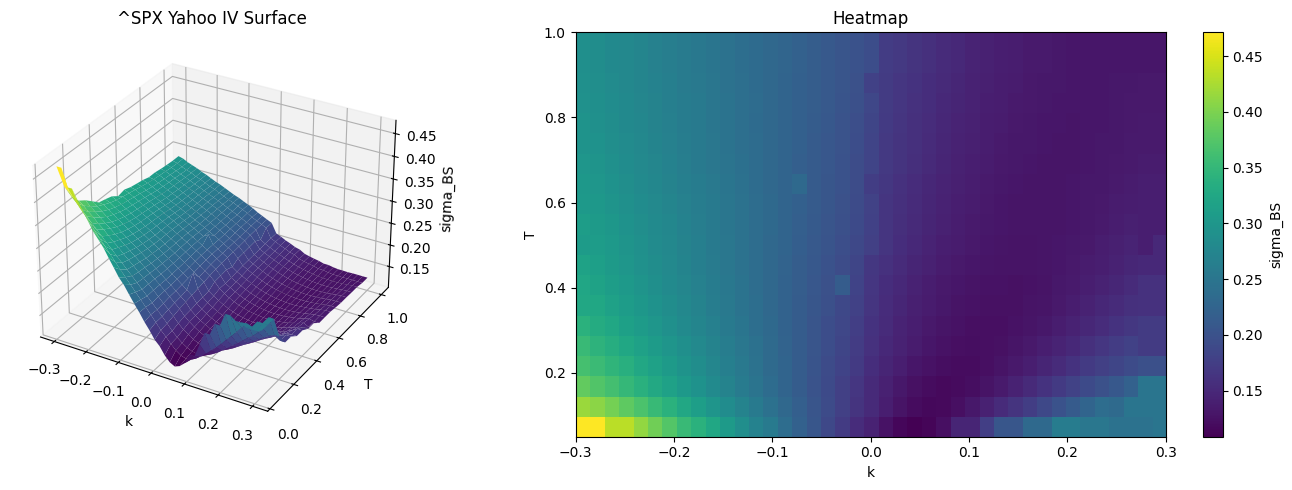

Synthetic surfaces shape: (250, 41, 20)


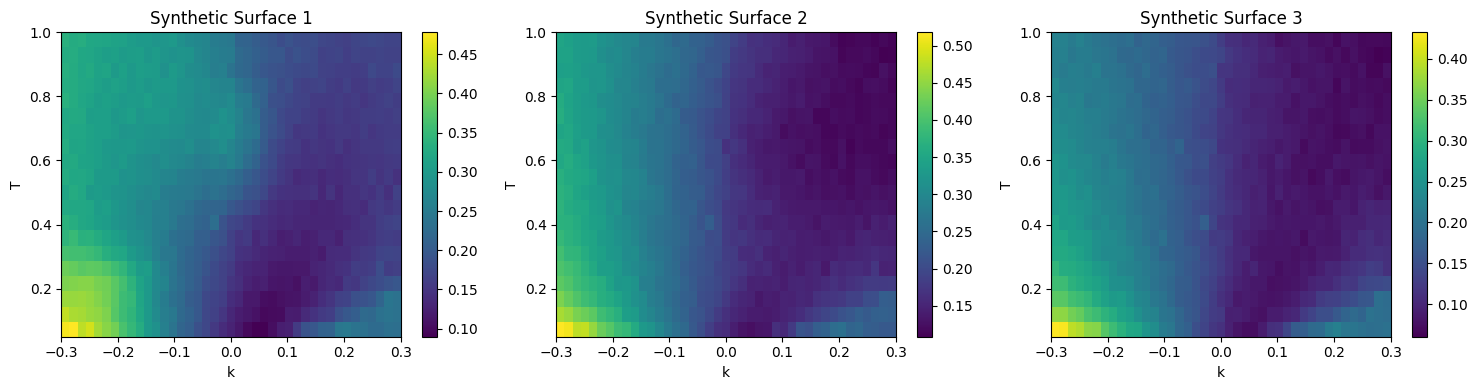

Sanity check raw Asian price: 144.1069589444378
Sanity check normalized Asian price V/S0: 0.019851575607221002


Generating local-vol MC labels:   0%|          | 0/250 [00:00<?, ?it/s]

X_surface: (5000, 41, 20)
X_contract [k,T,single_iv]: (5000, 3)
y_raw V: (5000, 1)
y_norm V/S0: (5000, 1)
S0_sample: (5000, 1)

Raw price summary:
count    5000.000000
mean      572.683044
std       639.861389
min         0.000000
25%         1.070436
50%       268.321777
75%      1126.304474
max      1986.365356
dtype: float64

Normalized price V/S0 summary:
count    5000.000000
mean        0.078890
std         0.088145
min         0.000000
25%         0.000147
50%         0.036963
75%         0.155155
max         0.273633
dtype: float64
Train samples: 3750
Test samples: 1250
Train y_norm scaled mean/std: -1.2207031e-08 1.0


Training VAE-style compressor:   0%|          | 0/300 [00:00<?, ?it/s]

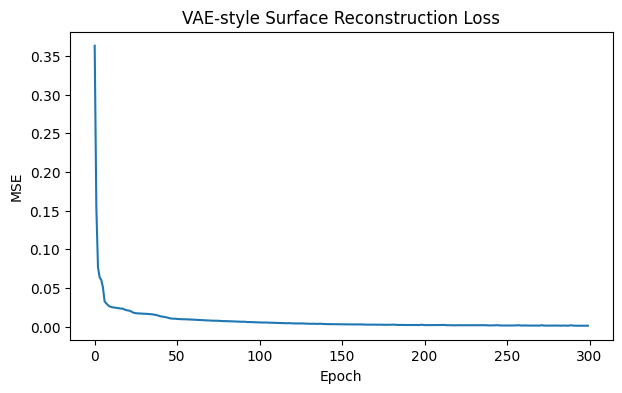

Z_train: (3750, 10)
Z_test: (1250, 10)


Training MLP:   0%|          | 0/300 [00:00<?, ?it/s]

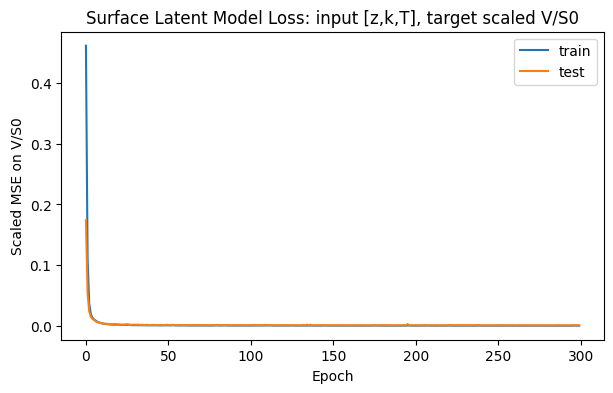

Training MLP:   0%|          | 0/300 [00:00<?, ?it/s]

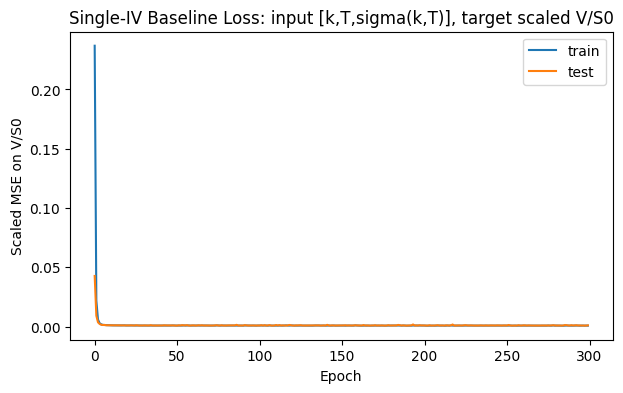

,Model,MAE_raw_price,RMSE_raw_price,MAPE_raw_price,MAE_norm_V_over_S,RMSE_norm_V_over_S,MAPE_norm_V_over_S
0,"Surface latent [z,k,T]",13.529013,18.924553,108939640.0,0.001864,0.002607,15047.431641
1,"Single IV [k,T,iv]",14.432656,21.437981,35470716.0,0.001988,0.002953,4891.922363


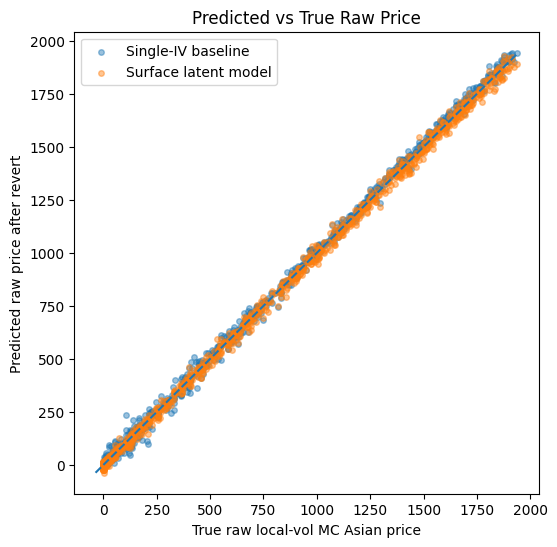

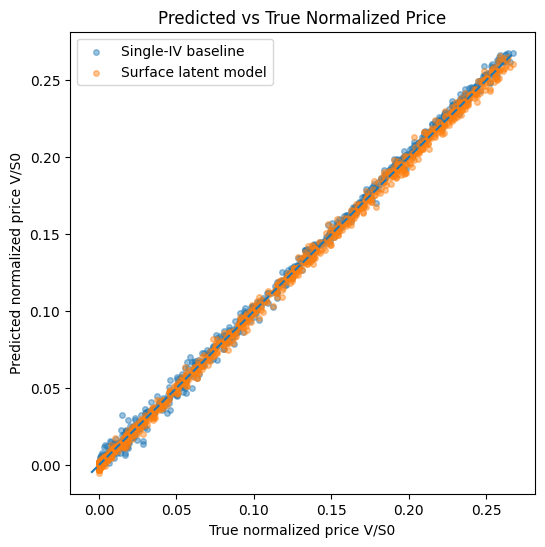

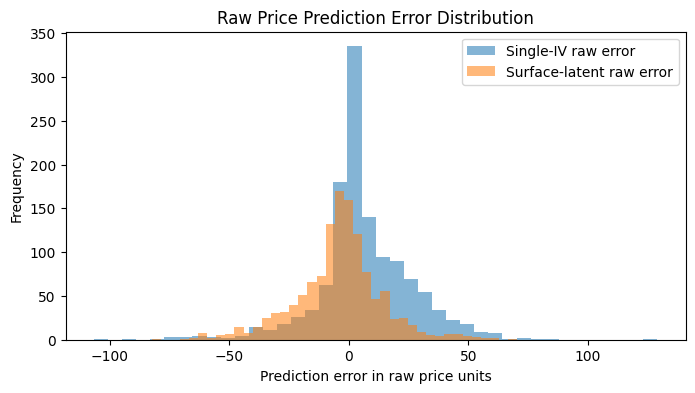

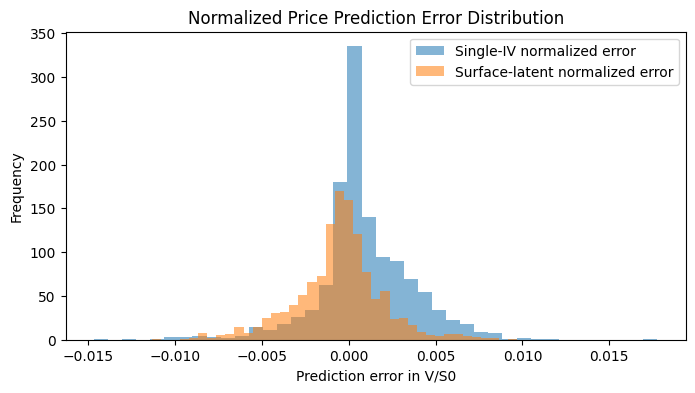

Saved outputs to: local_vol_surface_pricing_experiment_v_over_s

Numerical experiment summary:

I constructed an implied volatility surface from Yahoo Finance option-chain data.
For each strike and maturity, I selected the out-of-the-money side of the option chain
and solved the Black-Scholes implied volatility from the bid-ask mid price. The irregular
option-chain data were transformed into log-moneyness k = log(K/S0) and interpolated onto
a fixed 41 x 20 grid over k and maturity T.

The Asian option labels were generated using a local-volatility-style Monte Carlo simulation.
The MC simulation is still run in the original spot scale using the real S0 and the strike
K = S0 * exp(k). However, instead of training the neural network on the raw option price V,
I normalize the label as V/S0. The neural network therefore learns a relative pricing function
rather than a raw dollar/index-point price function.

After prediction, I first invert the StandardScaler applied to V/S0 and then multipl

In [1]:
# ============================================================
# Yahoo IV Surface -> Local-Vol-style MC Labels -> VAE-style Encoder + MLP Pricer
#
# Modified version:
#   1. MC still prices in real S0 scale.
#   2. Dataset stores raw price V and normalized label V/S0.
#   3. Neural network trains on scaled normalized label.
#   4. Evaluation reverts:
#          pred_norm = inverse_transform(pred_scaled)
#          pred_raw  = pred_norm * S0_sample
#
# Goal:
#   Avoid raw-price label scale problem across different spot levels.
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 2. Config
# ============================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

SYMBOL = "^SPX"       # If ^SPX fails, code will switch to SPY
RISK_FREE_RATE = 0.04
DIVIDEND_YIELD = 0.00

# Surface grid in log-moneyness k = log(K / S0)
K_MIN, K_MAX = -0.30, 0.30
T_MIN, T_MAX = 0.05, 1.00

N_K = 41
N_T = 20

k_grid = np.linspace(K_MIN, K_MAX, N_K)
T_grid = np.linspace(T_MIN, T_MAX, N_T)

# Synthetic experiment size
N_SYN_SURFACES = 250
N_OPTIONS_PER_SURFACE = 20

# Local-vol MC settings
N_MC_PATHS = 800
N_MC_STEPS = 32
OPTION_TYPE = "call"   # "call" or "put" for Asian option label

# Model settings
LATENT_DIM = 10
BATCH_SIZE = 128
VAE_EPOCHS = 300
MLP_EPOCHS = 300
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = Path("local_vol_surface_pricing_experiment_v_over_s")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", device)
print("Initial symbol:", SYMBOL)


# ============================================================
# 3. Black-Scholes helpers for IV solving
# ============================================================

def bs_price(S, K, T, r, q, sigma, option_type):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    if option_type == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

    raise ValueError("option_type must be 'call' or 'put'")


def implied_vol_from_mid(mid, S, K, T, r, q, option_type):
    if not np.isfinite(mid) or mid <= 0 or T <= 0 or S <= 0 or K <= 0:
        return np.nan

    def objective(sig):
        return bs_price(S, K, T, r, q, sig, option_type) - mid

    try:
        return brentq(objective, 1e-6, 5.0, maxiter=200)
    except Exception:
        return np.nan


# ============================================================
# 4. Fetch Yahoo option chain
# ============================================================

def fetch_yahoo_chain(symbol):
    tk = yf.Ticker(symbol)

    hist = tk.history(period="10d")
    if hist.empty:
        raise RuntimeError(f"Cannot fetch spot price for {symbol}")

    S0 = float(hist["Close"].dropna().iloc[-1])
    expiries = list(tk.options)

    if len(expiries) == 0:
        raise RuntimeError(f"No option expiries found for {symbol}")

    today = pd.Timestamp.today(tz=None).normalize()
    rows = []

    for exp in tqdm(expiries, desc=f"Fetching Yahoo option chains for {symbol}"):
        exp_date = pd.Timestamp(exp)
        T = (exp_date - today).days / 365.0

        if T < T_MIN or T > T_MAX:
            continue

        try:
            chain = tk.option_chain(exp)
        except Exception:
            continue

        calls = chain.calls.copy()
        puts = chain.puts.copy()

        calls["option_type"] = "call"
        puts["option_type"] = "put"

        df = pd.concat([calls, puts], ignore_index=True)
        df["expiry"] = exp
        df["T"] = T
        df["S0"] = S0
        df["K"] = pd.to_numeric(df["strike"], errors="coerce")
        df["k"] = np.log(df["K"] / S0)

        rows.append(df)

    if len(rows) == 0:
        raise RuntimeError("No valid option chain in selected maturity range.")

    raw = pd.concat(rows, ignore_index=True)
    return S0, raw


try:
    S0, raw_chain = fetch_yahoo_chain(SYMBOL)
except Exception as e:
    print("Failed with ^SPX:", e)
    print("Switching to SPY.")
    SYMBOL = "SPY"
    S0, raw_chain = fetch_yahoo_chain(SYMBOL)

print("Final symbol:", SYMBOL)
print("Spot S0:", S0)
print("Raw option chain shape:", raw_chain.shape)
display(raw_chain.head())


# ============================================================
# 5. Select OTM options and solve BS IV
# ============================================================

def prepare_otm_iv_points(raw_chain, S0):
    df = raw_chain.copy()

    for col in ["bid", "ask", "lastPrice", "impliedVolatility", "K", "T", "k"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["mid"] = (df["bid"] + df["ask"]) / 2.0

    bad_mid = (~np.isfinite(df["mid"])) | (df["mid"] <= 0)
    df.loc[bad_mid, "mid"] = df.loc[bad_mid, "lastPrice"]

    df["yahoo_iv"] = df["impliedVolatility"]

    # OTM rule:
    # K < S0 -> use OTM put
    # K > S0 -> use OTM call
    otm_puts = df[(df["option_type"] == "put") & (df["K"] < S0)].copy()
    otm_calls = df[(df["option_type"] == "call") & (df["K"] > S0)].copy()

    otm = pd.concat([otm_puts, otm_calls], ignore_index=True)

    otm = otm[
        (otm["k"] >= K_MIN) &
        (otm["k"] <= K_MAX) &
        (otm["T"] >= T_MIN) &
        (otm["T"] <= T_MAX) &
        (otm["mid"] > 0) &
        np.isfinite(otm["mid"])
    ].copy()

    if otm.empty:
        raise RuntimeError("No OTM options left after filtering. Try SPY or loosen ranges.")

    solved = []

    for row in tqdm(otm.itertuples(index=False), total=len(otm), desc="Solving BS IV"):
        iv = implied_vol_from_mid(
            mid=row.mid,
            S=row.S0,
            K=row.K,
            T=row.T,
            r=RISK_FREE_RATE,
            q=DIVIDEND_YIELD,
            option_type=row.option_type
        )
        solved.append(iv)

    otm["bs_iv_solved"] = solved
    otm["iv"] = otm["bs_iv_solved"]

    # Fallback to Yahoo IV if solver fails
    fallback = (~np.isfinite(otm["iv"])) | (otm["iv"] <= 0)
    otm.loc[fallback, "iv"] = otm.loc[fallback, "yahoo_iv"]

    otm = otm[
        np.isfinite(otm["iv"]) &
        (otm["iv"] > 0.01) &
        (otm["iv"] < 3.00)
    ].copy()

    otm = otm.sort_values(["T", "K"]).reset_index(drop=True)

    return otm


iv_points = prepare_otm_iv_points(raw_chain, S0)

print("OTM IV points:", iv_points.shape)
print(iv_points[["expiry", "option_type", "K", "k", "T", "mid", "iv"]].head())
print(iv_points["iv"].describe())


# ============================================================
# 6. Interpolate to fixed IV surface grid
# ============================================================

def interpolate_iv_surface(iv_points, k_grid, T_grid):
    points = iv_points[["k", "T"]].values
    values = iv_points["iv"].values

    linear_interp = LinearNDInterpolator(points, values)
    nearest_interp = NearestNDInterpolator(points, values)

    K_mesh, T_mesh = np.meshgrid(k_grid, T_grid, indexing="ij")
    query = np.column_stack([K_mesh.ravel(), T_mesh.ravel()])

    surf_linear = linear_interp(query).reshape(len(k_grid), len(T_grid))
    surf_nearest = nearest_interp(query).reshape(len(k_grid), len(T_grid))

    surface = np.where(np.isnan(surf_linear), surf_nearest, surf_linear)
    surface = np.clip(surface, 0.01, 3.00)

    return surface.astype(np.float32)


base_surface = interpolate_iv_surface(iv_points, k_grid, T_grid)

print("Base surface shape:", base_surface.shape)
print("Base surface min/max:", base_surface.min(), base_surface.max())

K_mesh, T_mesh = np.meshgrid(k_grid, T_grid, indexing="ij")

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(K_mesh, T_mesh, base_surface, cmap="viridis", linewidth=0)
ax1.set_xlabel("k")
ax1.set_ylabel("T")
ax1.set_zlabel("sigma_BS")
ax1.set_title(f"{SYMBOL} Yahoo IV Surface")

ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(
    base_surface.T,
    origin="lower",
    aspect="auto",
    extent=[K_MIN, K_MAX, T_MIN, T_MAX],
    cmap="viridis"
)
ax2.set_xlabel("k")
ax2.set_ylabel("T")
ax2.set_title("Heatmap")
fig.colorbar(im, ax=ax2, label="sigma_BS")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Generate synthetic volatility surfaces
# ============================================================

def augment_surface(base_surface):
    K_mesh, T_mesh = np.meshgrid(k_grid, T_grid, indexing="ij")

    level = np.random.normal(0.0, 0.025)
    skew = np.random.normal(0.0, 0.08)
    curvature = np.random.normal(0.0, 0.06)
    term = np.random.normal(0.0, 0.04)
    twist = np.random.normal(0.0, 0.03)
    noise = np.random.normal(0.0, 0.004, size=base_surface.shape)

    global_perturb = (
        level
        + skew * K_mesh
        + curvature * (K_mesh**2 - np.mean(k_grid**2))
        + term * (T_mesh - np.mean(T_grid))
        + twist * K_mesh * (T_mesh - np.mean(T_grid))
        + noise
    )

    n_bumps = np.random.randint(1, 4)
    local_bump = np.zeros_like(base_surface, dtype=np.float32)

    for _ in range(n_bumps):
        bump_k = np.random.uniform(-0.25, 0.25)
        bump_T = np.random.uniform(0.10, 0.90)
        bump_amp = np.random.normal(0.0, 0.05)
        bump_width_k = np.random.uniform(0.04, 0.10)
        bump_width_T = np.random.uniform(0.08, 0.20)

        bump = bump_amp * np.exp(
            -0.5 * ((K_mesh - bump_k) / bump_width_k) ** 2
            -0.5 * ((T_mesh - bump_T) / bump_width_T) ** 2
        )

        local_bump += bump.astype(np.float32)

    surface = base_surface + global_perturb + local_bump
    surface = np.clip(surface, 0.05, 1.50)

    return surface.astype(np.float32)


surfaces = np.stack(
    [augment_surface(base_surface) for _ in range(N_SYN_SURFACES)],
    axis=0
)

print("Synthetic surfaces shape:", surfaces.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(
        surfaces[i].T,
        origin="lower",
        aspect="auto",
        extent=[K_MIN, K_MAX, T_MIN, T_MAX],
        cmap="viridis"
    )
    ax.set_title(f"Synthetic Surface {i+1}")
    ax.set_xlabel("k")
    ax.set_ylabel("T")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


# ============================================================
# 8. Fast bilinear interpolation from surface
# ============================================================

def bilinear_surface_iv_scalar(surface, k, T):
    k = float(np.clip(k, k_grid[0], k_grid[-1]))
    T = float(np.clip(T, T_grid[0], T_grid[-1]))

    i = np.searchsorted(k_grid, k) - 1
    j = np.searchsorted(T_grid, T) - 1

    i = int(np.clip(i, 0, len(k_grid) - 2))
    j = int(np.clip(j, 0, len(T_grid) - 2))

    k0, k1 = k_grid[i], k_grid[i + 1]
    T0, T1 = T_grid[j], T_grid[j + 1]

    q00 = surface[i, j]
    q10 = surface[i + 1, j]
    q01 = surface[i, j + 1]
    q11 = surface[i + 1, j + 1]

    wk = (k - k0) / (k1 - k0 + 1e-12)
    wT = (T - T0) / (T1 - T0 + 1e-12)

    val = (
        (1 - wk) * (1 - wT) * q00
        + wk * (1 - wT) * q10
        + (1 - wk) * wT * q01
        + wk * wT * q11
    )

    return float(np.clip(val, 0.01, 3.00))


def bilinear_surface_iv_vectorized(surface, k_values, T_value):
    k_values = np.asarray(k_values, dtype=np.float64)
    k_values = np.clip(k_values, k_grid[0], k_grid[-1])
    T_value = float(np.clip(T_value, T_grid[0], T_grid[-1]))

    i = np.searchsorted(k_grid, k_values) - 1
    j = np.searchsorted(T_grid, T_value) - 1

    i = np.clip(i, 0, len(k_grid) - 2).astype(int)
    j = int(np.clip(j, 0, len(T_grid) - 2))

    k0 = k_grid[i]
    k1 = k_grid[i + 1]
    T0 = T_grid[j]
    T1 = T_grid[j + 1]

    q00 = surface[i, j]
    q10 = surface[i + 1, j]
    q01 = surface[i, j + 1]
    q11 = surface[i + 1, j + 1]

    wk = (k_values - k0) / (k1 - k0 + 1e-12)
    wT = (T_value - T0) / (T1 - T0 + 1e-12)

    vals = (
        (1 - wk) * (1 - wT) * q00
        + wk * (1 - wT) * q10
        + (1 - wk) * wT * q01
        + wk * wT * q11
    )

    return np.clip(vals, 0.01, 3.00)


# ============================================================
# 9. Local-vol-style Monte Carlo pricer
# ============================================================
#
# This still prices in real S0 scale.
# Later we divide the raw price by S0 to form the training label.
# ============================================================

def local_vol_asian_mc_price(
    surface,
    S0,
    k_contract,
    T_contract,
    option_type="call",
    r=0.04,
    q=0.00,
    n_paths=800,
    n_steps=32,
    seed=None
):
    rng = np.random.default_rng(seed)

    K = S0 * np.exp(k_contract)
    dt = T_contract / n_steps

    S = np.full(n_paths, S0, dtype=np.float64)
    running_sum = np.zeros(n_paths, dtype=np.float64)

    for step in range(1, n_steps + 1):
        u = step * dt

        # Path log-moneyness relative to original S0.
        k_path = np.log(S / S0)

        # Local-vol-style lookup.
        sigma_path = bilinear_surface_iv_vectorized(surface, k_path, u)

        Z = rng.standard_normal(n_paths)

        S = S * np.exp(
            (r - q - 0.5 * sigma_path**2) * dt
            + sigma_path * np.sqrt(dt) * Z
        )

        running_sum += S

    S_avg = running_sum / n_steps

    if option_type == "call":
        payoff = np.maximum(S_avg - K, 0.0)
    elif option_type == "put":
        payoff = np.maximum(K - S_avg, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    price = np.exp(-r * T_contract) * np.mean(payoff)

    return float(price)


test_price_raw = local_vol_asian_mc_price(
    surface=base_surface,
    S0=S0,
    k_contract=0.0,
    T_contract=0.25,
    option_type=OPTION_TYPE,
    r=RISK_FREE_RATE,
    q=DIVIDEND_YIELD,
    n_paths=2000,
    n_steps=N_MC_STEPS,
    seed=SEED
)

print("Sanity check raw Asian price:", test_price_raw)
print("Sanity check normalized Asian price V/S0:", test_price_raw / S0)


# ============================================================
# 10. Generate supervised dataset
# ============================================================
#
# Original:
#     y = raw MC price V
#
# Modified:
#     y_raw  = raw MC price V
#     y_norm = V / S0_sample
#
# For current single-date experiment:
#     S0_sample is constant.
#
# For future multi-date experiment:
#     S0_sample should be the spot on each surface date.
# ============================================================

def generate_local_vol_dataset(surfaces, S0):
    X_surface = []
    X_contract = []

    y_raw = []
    y_norm = []
    S0_sample = []

    sample_id = 0

    for s_idx in tqdm(range(len(surfaces)), desc="Generating local-vol MC labels"):
        surface = surfaces[s_idx]

        # Current experiment uses one current spot for all synthetic surfaces.
        # In a multi-date setting, replace this with S0_t for this surface date.
        S0_t = float(S0)

        for _ in range(N_OPTIONS_PER_SURFACE):
            k_contract = np.random.uniform(K_MIN, K_MAX)
            T_contract = np.random.uniform(T_MIN, T_MAX)

            single_iv = bilinear_surface_iv_scalar(surface, k_contract, T_contract)

            price_raw = local_vol_asian_mc_price(
                surface=surface,
                S0=S0_t,
                k_contract=k_contract,
                T_contract=T_contract,
                option_type=OPTION_TYPE,
                r=RISK_FREE_RATE,
                q=DIVIDEND_YIELD,
                n_paths=N_MC_PATHS,
                n_steps=N_MC_STEPS,
                seed=SEED + sample_id
            )

            price_norm = price_raw / S0_t

            X_surface.append(surface.copy())
            X_contract.append([k_contract, T_contract, single_iv])

            y_raw.append(price_raw)
            y_norm.append(price_norm)
            S0_sample.append(S0_t)

            sample_id += 1

    X_surface = np.array(X_surface, dtype=np.float32)
    X_contract = np.array(X_contract, dtype=np.float32)

    y_raw = np.array(y_raw, dtype=np.float32).reshape(-1, 1)
    y_norm = np.array(y_norm, dtype=np.float32).reshape(-1, 1)
    S0_sample = np.array(S0_sample, dtype=np.float32).reshape(-1, 1)

    return X_surface, X_contract, y_raw, y_norm, S0_sample


X_surface, X_contract, y_raw, y_norm, S0_sample = generate_local_vol_dataset(surfaces, S0)

print("X_surface:", X_surface.shape)
print("X_contract [k,T,single_iv]:", X_contract.shape)
print("y_raw V:", y_raw.shape)
print("y_norm V/S0:", y_norm.shape)
print("S0_sample:", S0_sample.shape)

print("\nRaw price summary:")
print(pd.Series(y_raw.ravel()).describe())

print("\nNormalized price V/S0 summary:")
print(pd.Series(y_norm.ravel()).describe())


# ============================================================
# 11. Train/test split and normalization
# ============================================================

idx = np.arange(len(y_norm))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.25,
    random_state=SEED
)

X_surface_train = X_surface[train_idx]
X_surface_test = X_surface[test_idx]

X_contract_train = X_contract[train_idx]
X_contract_test = X_contract[test_idx]

y_raw_train = y_raw[train_idx]
y_raw_test = y_raw[test_idx]

y_norm_train = y_norm[train_idx]
y_norm_test = y_norm[test_idx]

S0_train = S0_sample[train_idx]
S0_test = S0_sample[test_idx]

# Normalize surfaces globally using train only.
surf_mean = X_surface_train.mean()
surf_std = X_surface_train.std() + 1e-8

X_surface_train_s = (X_surface_train - surf_mean) / surf_std
X_surface_test_s = (X_surface_test - surf_mean) / surf_std

# Normalize contract features [k, T, single_iv] using train only.
contract_scaler = StandardScaler()
X_contract_train_s = contract_scaler.fit_transform(X_contract_train)
X_contract_test_s = contract_scaler.transform(X_contract_test)

# Important:
# Scale normalized label V/S0, not raw V.
# This is optional numerical scaling after financial normalization.
y_norm_scaler = StandardScaler()
y_norm_train_s = y_norm_scaler.fit_transform(y_norm_train)
y_norm_test_s = y_norm_scaler.transform(y_norm_test)

print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))
print("Train y_norm scaled mean/std:", y_norm_train_s.mean(), y_norm_train_s.std())


# ============================================================
# 12. VAE-style surface compressor
# ============================================================

class VAEStyleSurfaceAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()

        input_dim = N_K * N_T

        self.encoder_backbone = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.mu_head = nn.Linear(128, latent_dim)
        self.log_s_head = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def encode(self, x):
        x_flat = x.view(x.shape[0], -1)
        h = self.encoder_backbone(x_flat)

        mu = self.mu_head(h)

        log_s = self.log_s_head(h)
        log_s = torch.clamp(log_s, -6.0, 2.0)
        s = torch.exp(log_s)

        return mu, s

    def reparameterize(self, mu, s):
        eps = torch.randn_like(mu)
        return mu + s * eps

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(z.shape[0], N_K, N_T)

    def forward(self, x, n_samples=10):
        mu, s = self.encode(x)

        recons = []
        for _ in range(n_samples):
            z = self.reparameterize(mu, s)
            x_hat = self.decode(z)
            recons.append(x_hat)

        x_hat_avg = torch.stack(recons, dim=0).mean(dim=0)

        return x_hat_avg, mu, s


def train_vae_style(model, X_train, epochs=300, batch_size=128, n_samples=10):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    losses = []

    for epoch in tqdm(range(epochs), desc="Training VAE-style compressor"):
        model.train()
        total = 0.0

        for (xb,) in dl:
            xb = xb.to(device)

            optimizer.zero_grad()

            x_hat, mu, s = model(xb, n_samples=n_samples)

            # Reconstruction-only objective.
            loss = loss_fn(x_hat, xb)

            loss.backward()
            optimizer.step()

            total += loss.item() * xb.shape[0]

        losses.append(total / len(ds))

    return losses


vae = VAEStyleSurfaceAE(latent_dim=LATENT_DIM)

vae_losses = train_vae_style(
    vae,
    X_surface_train_s,
    epochs=VAE_EPOCHS,
    batch_size=BATCH_SIZE,
    n_samples=10
)

plt.figure(figsize=(7, 4))
plt.plot(vae_losses)
plt.title("VAE-style Surface Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()


# ============================================================
# 13. Extract deterministic z = mu
# ============================================================

@torch.no_grad()
def encode_mu(model, X):
    model.eval()
    model = model.to(device)

    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    zs = []

    for i in range(0, len(X), 512):
        xb = X_tensor[i:i+512]
        mu, s = model.encode(xb)
        zs.append(mu.cpu().numpy())

    return np.vstack(zs)


Z_train = encode_mu(vae, X_surface_train_s)
Z_test = encode_mu(vae, X_surface_test_s)

z_scaler = StandardScaler()
Z_train_s = z_scaler.fit_transform(Z_train)
Z_test_s = z_scaler.transform(Z_test)

print("Z_train:", Z_train_s.shape)
print("Z_test:", Z_test_s.shape)


# ============================================================
# 14. MLP pricer
# ============================================================

class MLPricer(nn.Module):
    def __init__(self, input_dim, hidden=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(model, X_train, y_train, X_test, y_test, epochs=300, batch_size=128):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

    train_losses = []
    test_losses = []

    for epoch in tqdm(range(epochs), desc="Training MLP"):
        model.train()
        total = 0.0

        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            optimizer.step()

            total += loss.item() * xb.shape[0]

        train_losses.append(total / len(ds))

        model.eval()
        with torch.no_grad():
            test_loss = loss_fn(model(X_test_t), y_test_t).item()

        test_losses.append(test_loss)

    return train_losses, test_losses


# Surface latent model input:
#     [z, scaled k, scaled T]
#
# Contract columns are:
#     [k, T, single_iv]
X_surface_latent_train = np.column_stack([
    Z_train_s,
    X_contract_train_s[:, :2]
])

X_surface_latent_test = np.column_stack([
    Z_test_s,
    X_contract_test_s[:, :2]
])

surface_model = MLPricer(
    input_dim=X_surface_latent_train.shape[1],
    hidden=128
)

surface_train_losses, surface_test_losses = train_mlp(
    surface_model,
    X_surface_latent_train,
    y_norm_train_s,
    X_surface_latent_test,
    y_norm_test_s,
    epochs=MLP_EPOCHS,
    batch_size=BATCH_SIZE
)

plt.figure(figsize=(7, 4))
plt.plot(surface_train_losses, label="train")
plt.plot(surface_test_losses, label="test")
plt.title("Surface Latent Model Loss: input [z,k,T], target scaled V/S0")
plt.xlabel("Epoch")
plt.ylabel("Scaled MSE on V/S0")
plt.legend()
plt.show()


# ============================================================
# 15. Baseline model: [k, T, single IV]
# ============================================================

baseline_model = MLPricer(input_dim=3, hidden=128)

baseline_train_losses, baseline_test_losses = train_mlp(
    baseline_model,
    X_contract_train_s,
    y_norm_train_s,
    X_contract_test_s,
    y_norm_test_s,
    epochs=MLP_EPOCHS,
    batch_size=BATCH_SIZE
)

plt.figure(figsize=(7, 4))
plt.plot(baseline_train_losses, label="train")
plt.plot(baseline_test_losses, label="test")
plt.title("Single-IV Baseline Loss: input [k,T,sigma(k,T)], target scaled V/S0")
plt.xlabel("Epoch")
plt.ylabel("Scaled MSE on V/S0")
plt.legend()
plt.show()


# ============================================================
# 16. Evaluation
# ============================================================
#
# Model output:
#     pred_scaled_norm
#
# Revert scaler:
#     pred_norm = inverse_transform(pred_scaled_norm)
#
# Revert financial normalization:
#     pred_raw = pred_norm * S0_test
# ============================================================

@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)

    preds = []

    for i in range(0, len(X), 512):
        pred = model(X_t[i:i+512]).cpu().numpy()
        preds.append(pred)

    return np.vstack(preds)


pred_surface_norm_s = predict(surface_model, X_surface_latent_test)
pred_baseline_norm_s = predict(baseline_model, X_contract_test_s)

# Inverse StandardScaler: scaled V/S0 -> V/S0.
pred_surface_norm = y_norm_scaler.inverse_transform(pred_surface_norm_s)
pred_baseline_norm = y_norm_scaler.inverse_transform(pred_baseline_norm_s)

# Revert normalized price: V/S0 -> V.
pred_surface_raw = pred_surface_norm * S0_test
pred_baseline_raw = pred_baseline_norm * S0_test

true_norm = y_norm_test
true_raw = y_raw_test


def calc_metrics(y_true, y_pred):
    err = y_pred.ravel() - y_true.ravel()

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    mape = np.mean(np.abs(err) / (np.abs(y_true.ravel()) + 1e-8))

    return mae, rmse, mape


surface_metrics_raw = calc_metrics(true_raw, pred_surface_raw)
baseline_metrics_raw = calc_metrics(true_raw, pred_baseline_raw)

surface_metrics_norm = calc_metrics(true_norm, pred_surface_norm)
baseline_metrics_norm = calc_metrics(true_norm, pred_baseline_norm)

results = pd.DataFrame({
    "Model": [
        "Surface latent [z,k,T]",
        "Single IV [k,T,iv]"
    ],
    "MAE_raw_price": [
        surface_metrics_raw[0],
        baseline_metrics_raw[0]
    ],
    "RMSE_raw_price": [
        surface_metrics_raw[1],
        baseline_metrics_raw[1]
    ],
    "MAPE_raw_price": [
        surface_metrics_raw[2],
        baseline_metrics_raw[2]
    ],
    "MAE_norm_V_over_S": [
        surface_metrics_norm[0],
        baseline_metrics_norm[0]
    ],
    "RMSE_norm_V_over_S": [
        surface_metrics_norm[1],
        baseline_metrics_norm[1]
    ],
    "MAPE_norm_V_over_S": [
        surface_metrics_norm[2],
        baseline_metrics_norm[2]
    ]
})

display(results)

# Predicted vs true in raw price units.
plt.figure(figsize=(6, 6))
plt.scatter(true_raw, pred_baseline_raw, alpha=0.45, s=16, label="Single-IV baseline")
plt.scatter(true_raw, pred_surface_raw, alpha=0.45, s=16, label="Surface latent model")

mn = min(true_raw.min(), pred_surface_raw.min(), pred_baseline_raw.min())
mx = max(true_raw.max(), pred_surface_raw.max(), pred_baseline_raw.max())

plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True raw local-vol MC Asian price")
plt.ylabel("Predicted raw price after revert")
plt.title("Predicted vs True Raw Price")
plt.legend()
plt.show()

# Predicted vs true in normalized V/S0 units.
plt.figure(figsize=(6, 6))
plt.scatter(true_norm, pred_baseline_norm, alpha=0.45, s=16, label="Single-IV baseline")
plt.scatter(true_norm, pred_surface_norm, alpha=0.45, s=16, label="Surface latent model")

mn = min(true_norm.min(), pred_surface_norm.min(), pred_baseline_norm.min())
mx = max(true_norm.max(), pred_surface_norm.max(), pred_baseline_norm.max())

plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True normalized price V/S0")
plt.ylabel("Predicted normalized price V/S0")
plt.title("Predicted vs True Normalized Price")
plt.legend()
plt.show()

# Raw price error distribution.
plt.figure(figsize=(8, 4))
plt.hist((pred_baseline_raw - true_raw).ravel(), bins=40, alpha=0.55, label="Single-IV raw error")
plt.hist((pred_surface_raw - true_raw).ravel(), bins=40, alpha=0.55, label="Surface-latent raw error")
plt.xlabel("Prediction error in raw price units")
plt.ylabel("Frequency")
plt.title("Raw Price Prediction Error Distribution")
plt.legend()
plt.show()

# Normalized price error distribution.
plt.figure(figsize=(8, 4))
plt.hist((pred_baseline_norm - true_norm).ravel(), bins=40, alpha=0.55, label="Single-IV normalized error")
plt.hist((pred_surface_norm - true_norm).ravel(), bins=40, alpha=0.55, label="Surface-latent normalized error")
plt.xlabel("Prediction error in V/S0")
plt.ylabel("Frequency")
plt.title("Normalized Price Prediction Error Distribution")
plt.legend()
plt.show()


# ============================================================
# 17. Save outputs
# ============================================================

safe_symbol = SYMBOL.replace("^", "").replace("/", "_")

np.savez(
    OUTPUT_DIR / f"{safe_symbol}_local_vol_dataset_v_over_s.npz",
    base_surface=base_surface,
    surfaces=surfaces,
    X_surface=X_surface,
    X_contract=X_contract,

    # Save both raw and normalized labels.
    y_raw=y_raw,
    y_norm=y_norm,
    S0_sample=S0_sample,

    k_grid=k_grid,
    T_grid=T_grid,
    S0=S0,

    surf_mean=surf_mean,
    surf_std=surf_std,

    risk_free_rate=RISK_FREE_RATE,
    dividend_yield=DIVIDEND_YIELD,

    # Save scaler statistics manually for easier reuse.
    y_norm_scaler_mean=y_norm_scaler.mean_,
    y_norm_scaler_scale=y_norm_scaler.scale_
)

torch.save(vae.state_dict(), OUTPUT_DIR / "vae_style_surface_compressor.pt")
torch.save(surface_model.state_dict(), OUTPUT_DIR / "asian_local_vol_surface_latent_pricer_v_over_s.pt")
torch.save(baseline_model.state_dict(), OUTPUT_DIR / "asian_single_iv_baseline_v_over_s.pt")

iv_points.to_csv(OUTPUT_DIR / f"{safe_symbol}_otm_iv_points.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)


# ============================================================
# 18. Report paragraph
# ============================================================

print("""
Numerical experiment summary:

I constructed an implied volatility surface from Yahoo Finance option-chain data.
For each strike and maturity, I selected the out-of-the-money side of the option chain
and solved the Black-Scholes implied volatility from the bid-ask mid price. The irregular
option-chain data were transformed into log-moneyness k = log(K/S0) and interpolated onto
a fixed 41 x 20 grid over k and maturity T.

The Asian option labels were generated using a local-volatility-style Monte Carlo simulation.
The MC simulation is still run in the original spot scale using the real S0 and the strike
K = S0 * exp(k). However, instead of training the neural network on the raw option price V,
I normalize the label as V/S0. The neural network therefore learns a relative pricing function
rather than a raw dollar/index-point price function.

After prediction, I first invert the StandardScaler applied to V/S0 and then multiply the
result by the corresponding S0_sample to recover the raw option price. This makes the setup
more robust for future multi-date experiments, because the model is less exposed to spot-level
scale shifts across train and test periods.
""")